## **Notebook PC#02**
## Regularized ELM Classifier for the MNIST and CIFAR-10 database. Designed from scratch.
**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** Daniele Souza Gonçalves **RA:** 248029 <br>
**Aluno(a):** Joao Lucas Morais Ortiz **RA:** 297611 <br>

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from keras.datasets import mnist

(Xp, y), (Xtp, yt) = mnist.load_data()
Xa = Xp.reshape(Xp.shape[0], 784)
Xta = Xtp.reshape(Xtp.shape[0], 784)
X = Xa / 255.0
Xt = Xta / 255.0

print("Shape of X: ".ljust(10),  X.shape)
print("Shape of y: ".ljust(10),  y.shape)
print("Shape of Xt: ".ljust(10),  Xt.shape)
print("Shape of yt: ".ljust(10),  yt.shape)

Shape of X:  (60000, 784)
Shape of y:  (60000,)
Shape of Xt:  (10000, 784)
Shape of yt:  (10000,)


In [2]:
# Dataset balancing analysis
from tensorflow.keras.utils import to_categorical
import plotly.express as px

yy = to_categorical(y)
yyt = to_categorical(yt)
sum_along_columns1 = np.sum(yy, axis = 0)
print(sum_along_columns1)
sum_along_columns2 = np.sum(yyt, axis = 0)
print(sum_along_columns2)
fig1 = px.bar(x=range(10),y=sum_along_columns1, width=600, height=400,
              labels=dict(x="Class", y="Number of instances"), title="<b>Number of instances per class in the training dataset</b>")
fig1.update_layout(xaxis = dict(tickmode = 'linear', dtick = 1), title_x=0.5)
fig1.show()
fig2 = px.bar(x=range(10),y=sum_along_columns2, width=600, height=400,
              labels=dict(x="Class", y="Number of instances"), title="<b>Number of instances per class in the test dataset</b>")
fig2.update_layout(xaxis = dict(tickmode = 'linear', dtick = 1), title_x=0.5)
fig2.show()

[5923. 6742. 5958. 6131. 5842. 5421. 5918. 6265. 5851. 5949.]
[ 980. 1135. 1032. 1010.  982.  892.  958. 1028.  974. 1009.]


In [3]:
partition = 0.7

# Mixing the dataset before partitioning
index = np.arange(0,X.shape[0])
np.random.shuffle(index)

training_set_size = int(X.shape[0] * partition)

index_training = index[:training_set_size]
index_validation = index[training_set_size:]


X_training = X[index_training]
y_training = yy[index_training]

X_validation = X[index_validation]
y_validation = yy[index_validation]

# ELM X
# We will concatenate a column of 1's to account for the V0 of each hidden neuron later on
X_training_elm = np.concatenate((np.transpose(np.array([np.ones(X_training.shape[0])])), X_training), axis=1)
X_validation_elm = np.concatenate((np.transpose(np.array([np.ones(X_validation.shape[0])])), X_validation), axis=1)

print("X_training:".ljust(20), X_training.shape)
print("y_training:".ljust(20), y_training.shape)

print("X_validation:".ljust(20), X_validation.shape)
print("y_validation:".ljust(20), y_validation.shape)

print("X_training_elm:".ljust(20), X_training_elm.shape)
print("X_validation_elm:".ljust(20), X_validation_elm.shape)

X_training:          (42000, 784)
y_training:          (42000, 10)
X_validation:        (18000, 784)
y_validation:        (18000, 10)
X_training_elm:      (42000, 785)
X_validation_elm:    (18000, 785)


In [4]:
def get_class_from_sample(sample: np.ndarray):
    class_ = 1
    for i in sample:
        if i == 0:
            class_ += 1
        else:
            break
    return class_

In [5]:
def leaky_relu(table):
    return np.where(table > 0, table,  0.02 * table)

def relu(table):
    return np.where(table > 0, table,  0)

def get_h(X, V, activation_function):
    V_ = np.matmul(X, V)
    return activation_function(V_)

def get_w(X, y, c):
    w_1 = (np.matmul(np.transpose(X), X) + c * np.eye(X.shape[1]))
    w_2 = np.matmul(np.transpose(X), y)
    w,resid,rank,s = np.linalg.lstsq(w_1, w_2, rcond=None)
    return w

In [6]:
def get_rates_from_c_values(X, y, c_values, Ws = []):
    hit_rates = []

    if len(Ws) != 0:
        are_Ws_given = True
    else:
        are_Ws_given = False
        Ws = []

    for index, c in enumerate(c_values):
        print(c)

        if are_Ws_given:
            W = Ws[index]
        else:
            W = get_w(X, y, c)
            Ws.append(W)

        y_estimate = np.matmul(X,W)
        hits = 0
        for index, estimate in enumerate(y_estimate):
            max_index = np.where(estimate == np.amax(estimate))[0][0]
            estimated_class = max_index + 1
            if estimated_class == get_class_from_sample(y[index]):
                hits += 1
        hit_rates.append(hits/y_estimate.shape[0])
    return hit_rates, Ws

The larger weigth of the neural network hidden layer is: 0.9905585971620807
The smaller weigth of the neural network hidden layer is: -0.9386418042703122


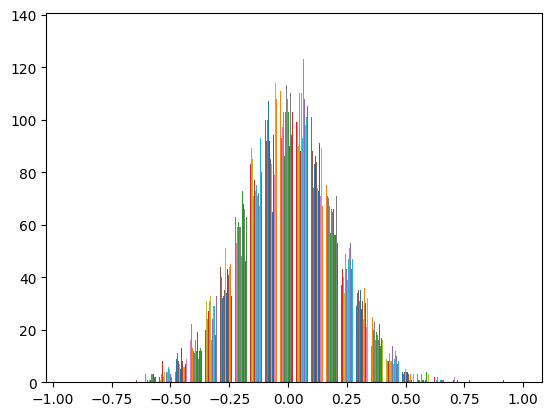

In [7]:
# Standard deviation of the random weight generation at the hidden layer
sigma = 0.2
# Number of inputs for the MNIST dataset: 785
# Take 1000 hidden neurons for the MNIST dataset
V  = sigma * np.random.randn(785, 1000)
max_value = max([max(l) for l in V])
min_value = min([min(l) for l in V])
print('The larger weigth of the neural network hidden layer is:', max_value)
print('The smaller weigth of the neural network hidden layer is:', min_value)
plt.hist(V, bins = 30)
plt.show()

####**Varying the weight variance (the range or distribution) of randomly generated hidden layer weights in an Extreme Learning Machine (ELM) significantly impacts its generalization ability, stability, and the diversity of information extracted. The variance of the weights affects the activation functions and, consequently, the conditioning of the hidden layer output matrix, which determines the final output weights. The variance depends directly on the sigma value of the above code.**

In [8]:
c_values = [pow(2,d) for d in range(-16, 15, 2)] # Range goes up to 15 to ensure search up to 2^14

hit_rates_training, Ws = get_rates_from_c_values(get_h(X_training_elm, V, relu), y_training, c_values)

1.52587890625e-05
6.103515625e-05
0.000244140625
0.0009765625
0.00390625
0.015625
0.0625
0.25
1
4
16
64
256
1024
4096
16384


In [9]:
hit_rates_validation, _ = get_rates_from_c_values(get_h(X_validation_elm, V, relu), y_validation, c_values, Ws)

1.52587890625e-05
6.103515625e-05
0.000244140625
0.0009765625
0.00390625
0.015625
0.0625
0.25
1
4
16
64
256
1024
4096
16384


Best c value: 4 
Performance of this value: 0.9405555555555556


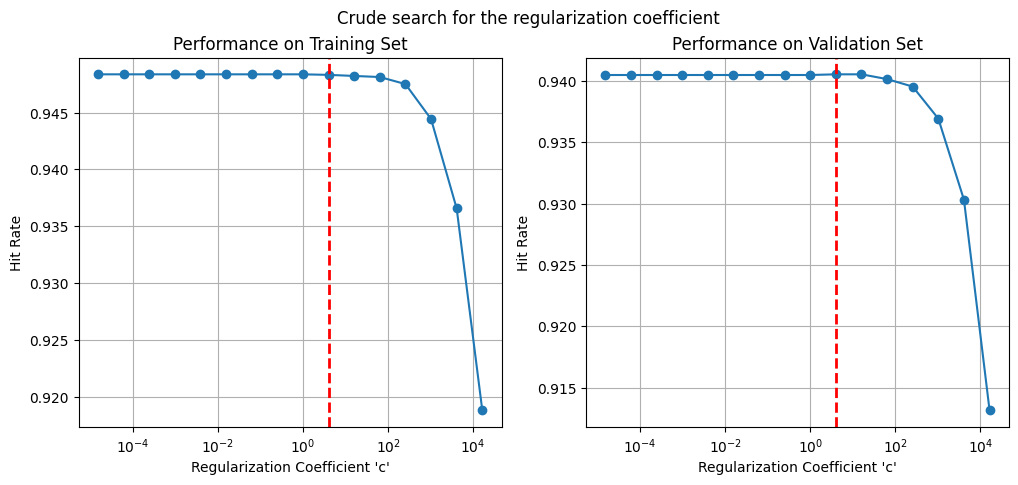

In [10]:
best_c_index = np.where(hit_rates_validation == np.amax(hit_rates_validation))[0][0]

best_c = c_values[best_c_index]

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.suptitle("Crude search for the regularization coefficient")
axs[0].semilogx(c_values, hit_rates_training, 'o-')
axs[0].set_title("Performance on Training Set")
axs[0].set_ylabel("Hit Rate")
axs[0].set_xlabel("Regularization Coefficient 'c'")
axs[0].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[0].grid()

axs[1].semilogx(c_values, hit_rates_validation, 'o-')
axs[1].set_title("Performance on Validation Set")
axs[1].set_ylabel("Hit Rate")
axs[1].set_xlabel("Regularization Coefficient 'c'")
axs[1].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[1].grid()

print("Best c value: {} \nPerformance of this value: {}".format(best_c, hit_rates_validation[best_c_index]))


**Nota**: Ao analisar o gráfico da direita acima, só corrija o intervalo de busca caso não haja uma queda de desempenho para valores elevados do coeficiente de regularização. Caso o melhor coeficiente de regularização seja o de menor valor, siga adiante, pois isso indica a ausência de necessidade de regularizar esta solução.

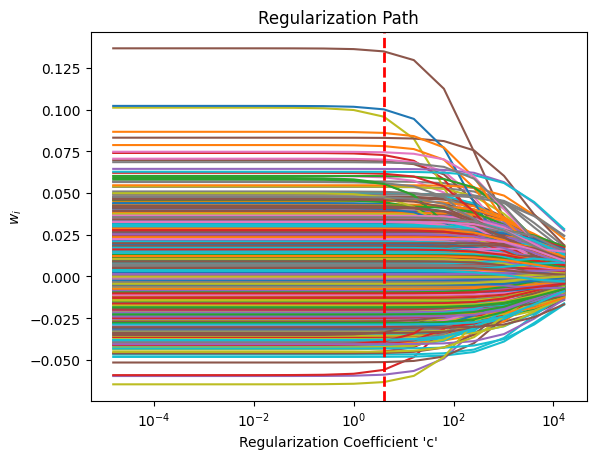

In [11]:
lambd_values = c_values
w_values = Ws

def plot_regularization_path(lambd_values, w_values):
    num_coeffs = len(w_values[0])
    for i in range(num_coeffs):
        plt.plot(lambd_values, [wi[i] for wi in w_values])
    plt.xlabel(r"Regularization Coefficient 'c'", fontsize=10)
    plt.ylabel(r"$w_i$", fontsize=10)
    plt.xscale("log")
    plt.title("Regularization Path")

plot_regularization_path(lambd_values, w_values)
plt.axvline(x=best_c, color='r', linestyle='--', linewidth=2)
plt.show()

<font color="green">
Atividade (a) <br>
Explique o comportamento das curvas [Regularization Path] e [Performance on Validation Set] logo acima, vinculando os seus comportamentos. <br>
</font>


Resposta: Analisando o gráfico Regularization Path, notamos que para valores muito pequenos de C, os pesos assumem magnitudes muito altas (valores extremos), o que força um sobreajuste  e resulta em uma pior (mesmo que ligeira) performance no conjunto de validação. À medida que o valor de C vai aumentando até chegar ao C ideal, ocorre a penalização esperada e os pesos vão se comprimindo gradativamente rumo a zero, estabilizando o modelo e atingindo sua capacidade máxima de generalização. Porém, ao ultrapassar o limite do C ideal, os pesos se aproximam de zero de forma excessiva, o que apaga o aprendizado da rede (subajuste) e faz com que o desempenho no conjunto de validação caia de forma abrupta e expressiva.

In [12]:
step =  0.1 * (4 * best_c - best_c / 4);

fine_c_values = np.arange((best_c/4), (4*best_c) + step / 10, step)

hit_rates_training_fine, Ws_fine = get_rates_from_c_values(get_h(X_training_elm, V, relu), y_training, fine_c_values)

1.0
2.5
4.0
5.5
7.0
8.5
10.0
11.5
13.0
14.5
16.0


In [13]:
hit_rates_validation_fine, _ = get_rates_from_c_values(get_h(X_validation_elm, V, relu), y_validation, fine_c_values, Ws_fine)

1.0
2.5
4.0
5.5
7.0
8.5
10.0
11.5
13.0
14.5
16.0


Best c value: 4.0 
Performance of this value: 0.9405555555555556


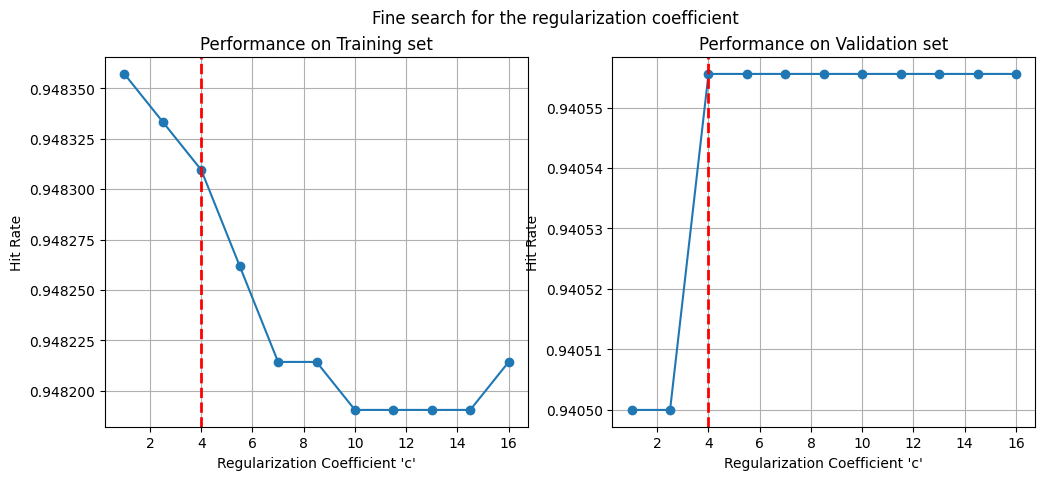

In [14]:
best_c_index = np.where(hit_rates_validation_fine == np.amax(hit_rates_validation_fine))[0][0]

best_c = fine_c_values[best_c_index]

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.suptitle("Fine search for the regularization coefficient")
axs[0].plot(fine_c_values, hit_rates_training_fine, 'o-')
axs[0].set_title("Performance on Training set")
axs[0].set_ylabel("Hit Rate")
axs[0].set_xlabel("Regularization Coefficient 'c'")
axs[0].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[0].grid()

axs[1].plot(fine_c_values, hit_rates_validation_fine, 'o-')
axs[1].set_title("Performance on Validation set")
axs[1].set_ylabel("Hit Rate")
axs[1].set_xlabel("Regularization Coefficient 'c'")
axs[1].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[1].grid()

print("Best c value: {} \nPerformance of this value: {}".format(best_c, hit_rates_validation_fine[best_c_index]))

(1000, 10)
The larger weigth of the neural network output layer is: 0.1365230247032986
The smaller weigth of the neural network output layer is: -0.06265583846108241


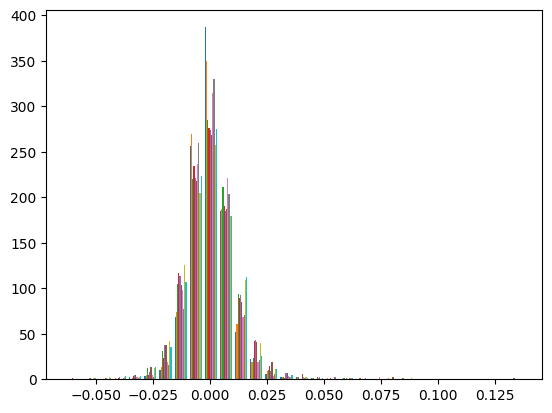

In [15]:
X_elm = np.concatenate((np.transpose(np.array([np.ones(X.shape[0])])), X), axis=1)
W_elm = get_w(get_h(X_elm, V, relu), yy, best_c)
print(W_elm.shape)
max_value = max([max(l) for l in W_elm])
min_value = min([min(l) for l in W_elm])
print('The larger weigth of the neural network output layer is:', max_value)
print('The smaller weigth of the neural network output layer is:', min_value)
plt.hist(W_elm, bins = 30)
plt.show()

In [16]:
Xt_elm = np.concatenate((np.transpose(np.array([np.ones(Xt.shape[0])])), Xt), axis=1)
yt_estimate = np.matmul(get_h(Xt_elm, V, relu),W_elm)
hits = 0
confusion_matrix = np.zeros([10, 10], dtype=int)
for index, estimate in enumerate(yt_estimate):
    max_index = np.where(estimate == np.amax(estimate))[0][0]
    estimated_class = max_index + 1
    if estimated_class == get_class_from_sample(yyt[index,:]):
        hits += 1
        confusion_matrix[estimated_class-1][estimated_class-1] += 1
    else:
        confusion_matrix[estimated_class-1][get_class_from_sample(yyt[index,:])-1] += 1

print("Performance on test set: {}".format(hits/yt_estimate.shape[0]))
confusion_matrix_df = pd.DataFrame(confusion_matrix)
confusion_matrix_df

Performance on test set: 0.9432


,0,1,2,3,4,5,6,7,8,9
0,959,0,6,4,2,7,10,3,10,5
1,0,1120,1,0,7,1,3,13,4,6
2,1,2,957,14,3,1,2,21,5,4
3,2,3,9,940,0,17,0,2,16,11
4,0,2,6,0,935,2,5,8,8,33
5,3,0,1,19,0,833,11,0,9,2
6,8,4,10,3,6,13,925,0,7,2
7,1,0,7,9,2,4,0,951,10,19
8,6,4,32,11,3,12,1,4,894,9
9,0,0,3,10,24,2,1,26,11,918


<font color="green">
Atividade (b) <br>
O que sustenta o ganho de desempenho na taxa de acerto de classificação quando comparado ao classificador linear do PC01? Repare que a estratégia de otimização é a mesma nos dois casos. <br>
</font>

Resposta: O ganho de desempenho é sustentado pela presença da camada intermediária da ELM, que realiza um mapeamento não-linear. Como a camada de saída da ELM continua implementando um classificador estritamente linear (exatamente como ocorria no PC01), o papel fundamental exercido pela matriz pré-processada com os neurônios da camada oculta é transformar os dados para um espaço dimensional diferente e tornar o problema de classificação mais linearmente separável para a camada de saída. Transformar o problema para que fique mais linear justifica a melhoria acentuada da capacidade de generalização e de acerto do modelo.

Image no. 33


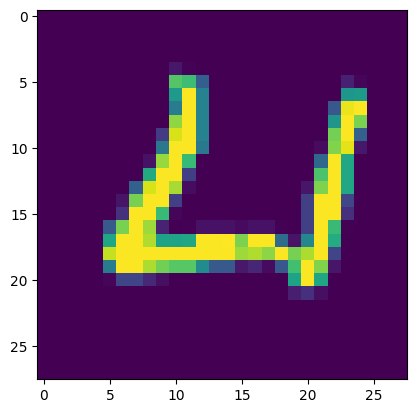

Real: 4
Predicted: 0
Rank of the correct answer: 2
Outputs: [ 0.48284612 -0.05305013 -0.00055666  0.24805059  0.41357294 -0.11042433
  0.2292929  -0.16703765 -0.09879013  0.02043721] 

Image no. 38


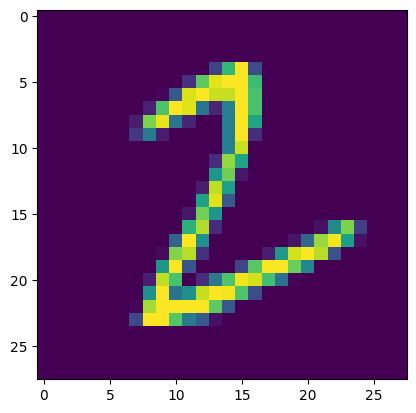

Real: 2
Predicted: 3
Rank of the correct answer: 3
Outputs: [ 0.00382087 -0.06985602  0.37257903  0.38726293  0.02595555  0.38127503
 -0.11501891 -0.10364135  0.02223107  0.08309197] 

Image no. 63


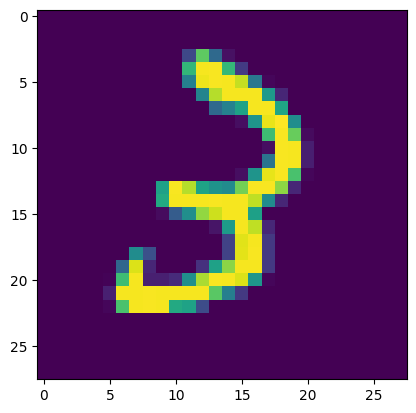

Real: 3
Predicted: 2
Rank of the correct answer: 2
Outputs: [-0.00871668 -0.00809503  0.60004536  0.37909777 -0.08306423 -0.00574817
 -0.09334692 -0.04885404  0.08801008  0.1433146 ] 

Image no. 73


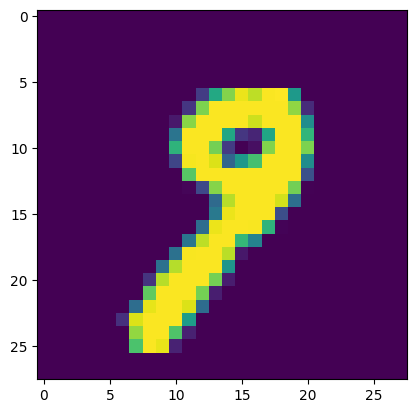

Real: 9
Predicted: 7
Rank of the correct answer: 2
Outputs: [-0.0391275  -0.11813109  0.05118304  0.14260224  0.07950719 -0.0798619
 -0.04842526  0.42317761  0.28530717  0.34103346] 

Image no. 115


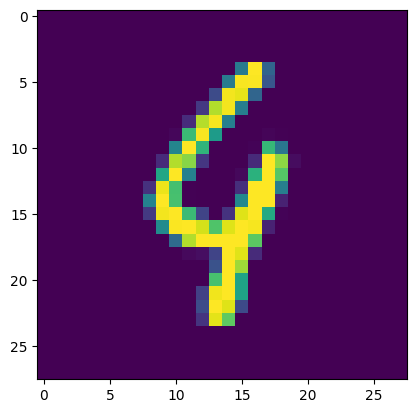

Real: 4
Predicted: 9
Rank of the correct answer: 2
Outputs: [ 0.00769456  0.23329682  0.05401283 -0.02784741  0.47269247 -0.21566636
  0.15779828 -0.04968058 -0.0744828   0.49504065] 

Image no. 124


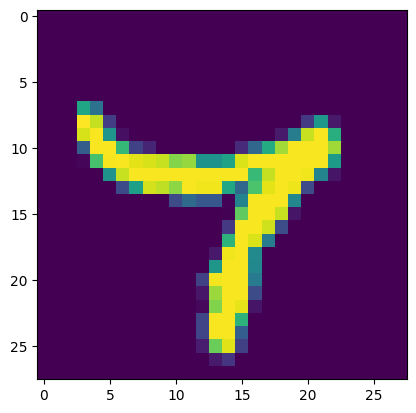

Real: 7
Predicted: 4
Rank of the correct answer: 3
Outputs: [-0.03654671 -0.09953514  0.07933294  0.25954746  0.66139819 -0.16531824
  0.02791477  0.24008801  0.02782434  0.09350053] 

Image no. 149


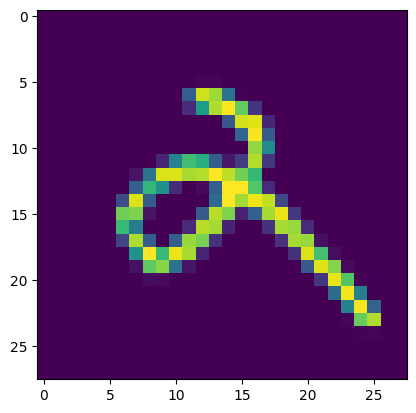

Real: 2
Predicted: 4
Rank of the correct answer: 3
Outputs: [-0.08305226  0.1635588   0.22446014 -0.03714735  0.44679947 -0.07469483
  0.07451716 -0.0945383   0.28588818  0.06596147] 

Image no. 193


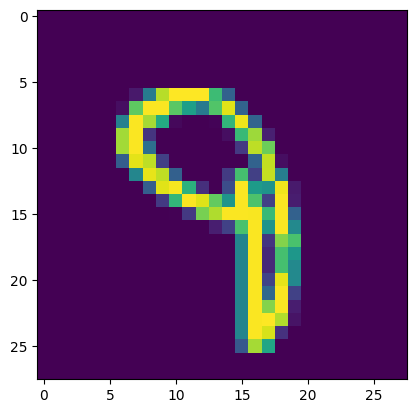

Real: 9
Predicted: 4
Rank of the correct answer: 2
Outputs: [-0.03182247  0.05405881  0.04643304  0.08986699  0.35429193  0.05481259
  0.10698603  0.07113912 -0.10368366  0.30927378] 

Image no. 217


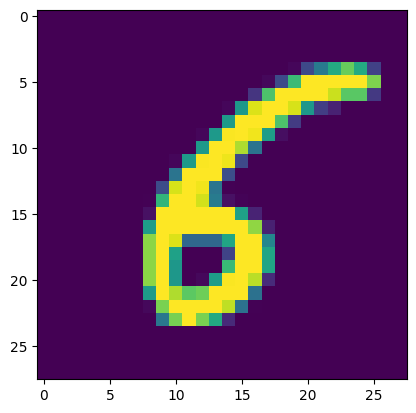

Real: 6
Predicted: 5
Rank of the correct answer: 2
Outputs: [ 0.05623366 -0.04006309  0.01385449 -0.14491848  0.04783034  0.69949653
  0.27299206 -0.04553961  0.08453319  0.07781701] 

Image no. 233


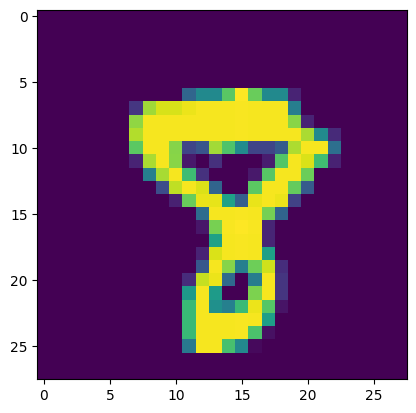

Real: 8
Predicted: 7
Rank of the correct answer: 2
Outputs: [-0.05027569 -0.07287664  0.06401662  0.02608764 -0.08461163  0.00697305
 -0.0135338   0.41448898  0.40097758  0.26014345] 

Image no. 241


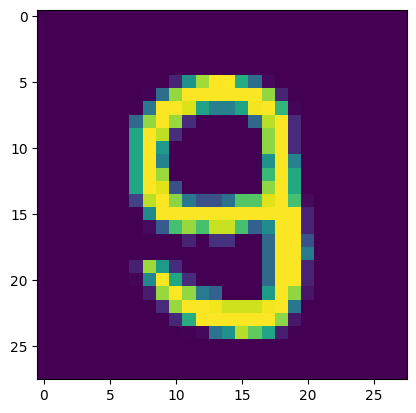

Real: 9
Predicted: 8
Rank of the correct answer: 6
Outputs: [ 0.13959787 -0.0160151   0.13910723  0.16289106 -0.00075182  0.17986605
  0.00431096 -0.08999952  0.34620276  0.09469106] 

Image no. 245


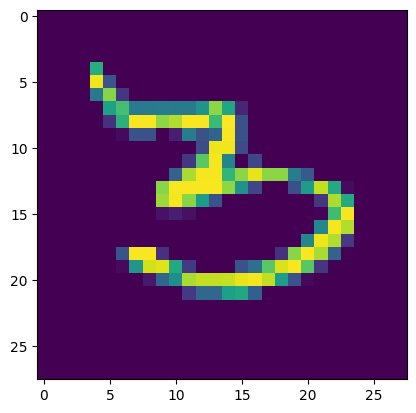

Real: 3
Predicted: 5
Rank of the correct answer: 3
Outputs: [-0.08440219  0.10526171  0.06368045  0.13781594  0.10676908  0.38864317
  0.30300222  0.05412766 -0.10691887 -0.01738978] 

Image no. 247


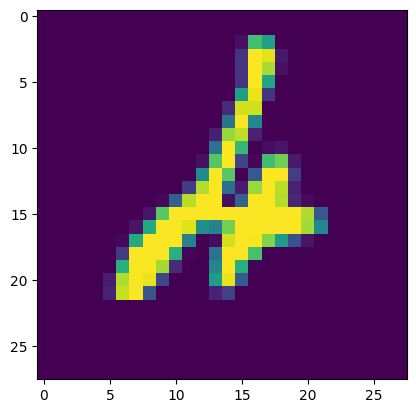

Real: 4
Predicted: 2
Rank of the correct answer: 4
Outputs: [-0.12350614  0.00435345  0.41949082  0.05889498  0.12063187  0.06340485
  0.2479319   0.02317163  0.16600002 -0.01355966] 

Image no. 259


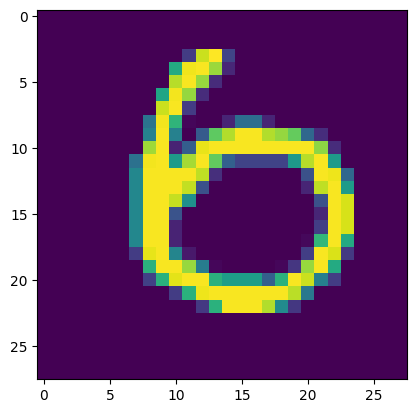

Real: 6
Predicted: 0
Rank of the correct answer: 2
Outputs: [ 0.64705277 -0.04158225 -0.06288888  0.2808455   0.13927567 -0.19828933
  0.32507684  0.24826114 -0.04428493 -0.26808453] 

Image no. 264


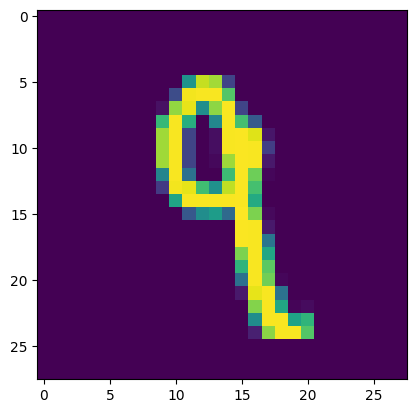

Real: 9
Predicted: 4
Rank of the correct answer: 2
Outputs: [-0.07847461  0.1677852   0.1012967   0.03521852  0.36191716  0.03303738
 -0.05446819  0.00718574  0.16779526  0.2784954 ] 

Image no. 289


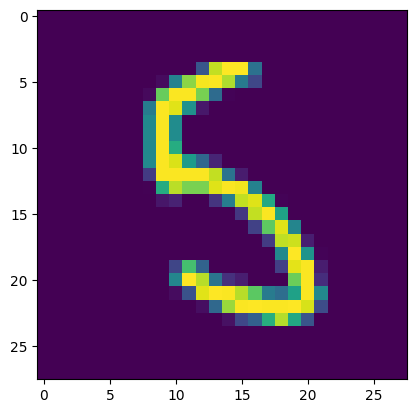

Real: 5
Predicted: 8
Rank of the correct answer: 2
Outputs: [ 0.05753807 -0.06277294 -0.02594835  0.18932952  0.1696247   0.30121786
  0.11337151  0.00448536  0.30565878 -0.10466089] 

Image no. 290


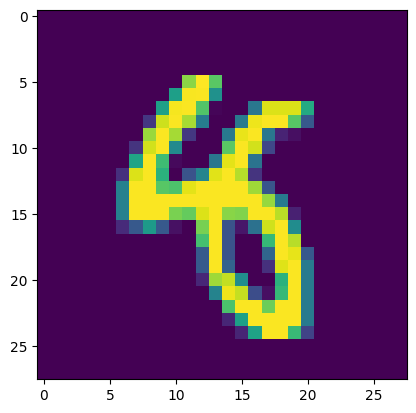

Real: 8
Predicted: 4
Rank of the correct answer: 2
Outputs: [-0.01213518 -0.02813339  0.01611616  0.29763387  0.3768744   0.02876262
 -0.04507777 -0.20433034  0.37158413  0.18033929] 

Image no. 300


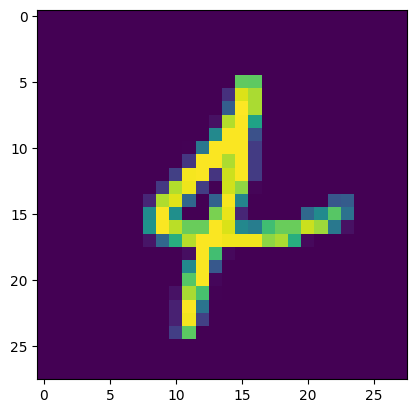

Real: 4
Predicted: 1
Rank of the correct answer: 3
Outputs: [-0.04521221  0.59060561 -0.15391367  0.08114213  0.29275951  0.01885379
  0.34345531  0.05915736 -0.11542486 -0.01577856] 

Image no. 313


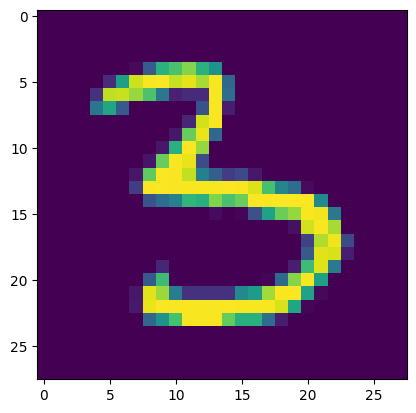

Real: 3
Predicted: 5
Rank of the correct answer: 2
Outputs: [-0.0216026  -0.05443006  0.08558534  0.41625677  0.06671667  0.53678452
 -0.01880706 -0.07277849  0.05490895 -0.01224431] 

Image no. 318


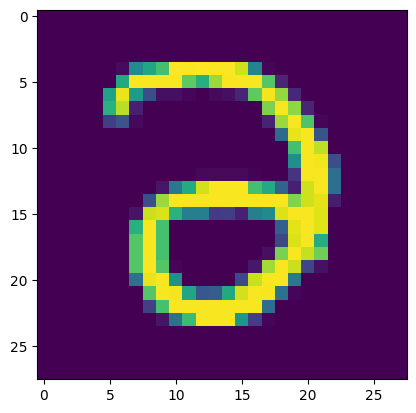

Real: 2
Predicted: 3
Rank of the correct answer: 3
Outputs: [ 3.56760474e-01  4.60585604e-04  2.45361228e-01  4.88491432e-01
  2.69150718e-03 -2.97533132e-01  2.40535007e-01 -1.38940061e-01
  1.73018479e-01 -7.50264731e-02] 

Image no. 320


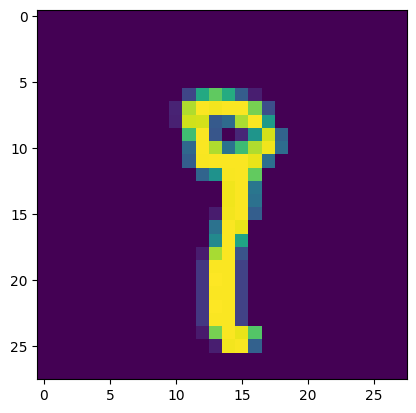

Real: 9
Predicted: 7
Rank of the correct answer: 3
Outputs: [-0.02609668  0.29215492 -0.06265938  0.08534995 -0.10592274  0.00811729
  0.08389856  0.30873119  0.12979902  0.16158585] 

Image no. 321


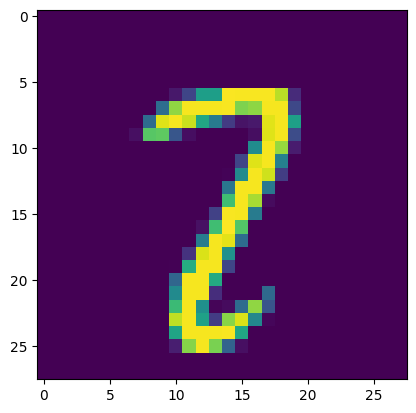

Real: 2
Predicted: 7
Rank of the correct answer: 3
Outputs: [-0.04870856 -0.08049565  0.16005702  0.15527545 -0.1986707   0.10983524
  0.12454034  0.58544272  0.29335024 -0.02524546] 

Image no. 324


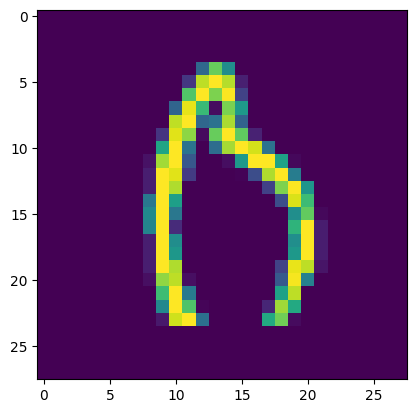

Real: 0
Predicted: 3
Rank of the correct answer: 3
Outputs: [ 0.17235809 -0.09163133  0.11225619  0.19532469  0.0296796   0.1887266
  0.07733826  0.06373197  0.06718124  0.09288197] 

Image no. 340


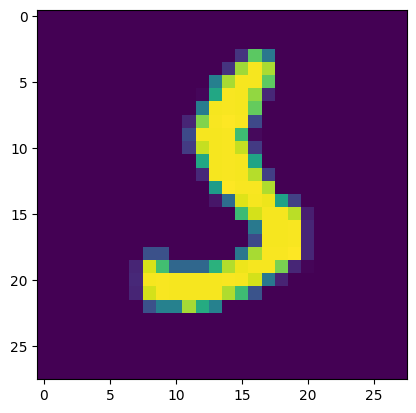

Real: 5
Predicted: 3
Rank of the correct answer: 3
Outputs: [-0.10978625  0.07747716 -0.11136748  0.56028896  0.09862935  0.27746376
  0.28132203 -0.08784615 -0.01651983  0.02499282] 

Image no. 352


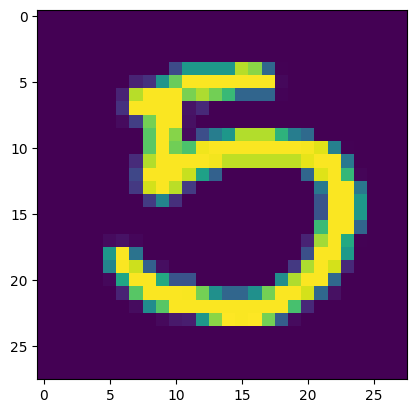

Real: 5
Predicted: 0
Rank of the correct answer: 3
Outputs: [ 0.42066548 -0.14077681  0.03198528  0.16146552  0.02230082  0.27011658
 -0.04459438  0.27031915 -0.07066958  0.07357151] 

Image no. 362


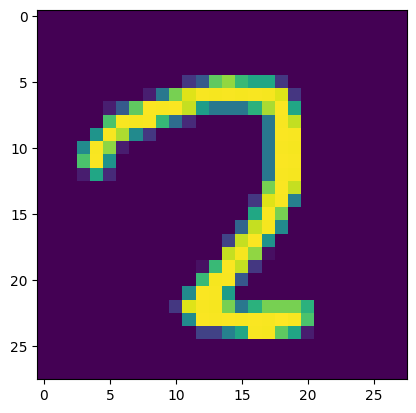

Real: 2
Predicted: 0
Rank of the correct answer: 2
Outputs: [ 0.32528947  0.04781774  0.2696924   0.24721161  0.15301694 -0.04898961
 -0.22903969  0.19895005  0.08888038  0.0627313 ] 

Image no. 381


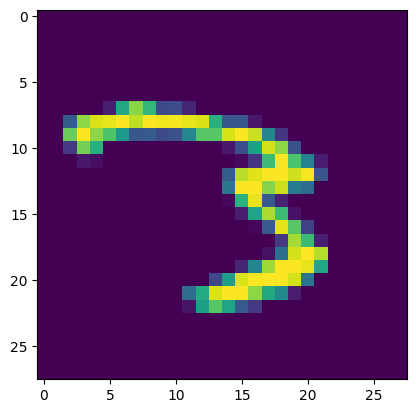

Real: 3
Predicted: 7
Rank of the correct answer: 3
Outputs: [-0.10945034 -0.04148937  0.05828307  0.22604941  0.0493474   0.04437658
  0.27447095  0.34376102  0.0512961  -0.01311438] 



In [17]:
# Devoted solely to the MNIST dataset
def find_pos(item, lst):
    pos = [i for (z, i) in zip(lst, range(len(lst))) if item == z]
    return pos

def display_sample(sample: np.ndarray):

    sample = np.array(sample, dtype='float')
    pixels = np.zeros((28,28))

    for i in range(28):
        for j in range(28):
            pixels[i,j] = sample[i * 28 + j]

    pixels = pixels.reshape((28, 28))
    plt.imshow(pixels, cmap='viridis')
    plt.show()

yt_estimate = np.matmul(get_h(Xt_elm, V, relu),W_elm)
rank_of_correct_answer = []
for i in range(400):
    if yyt[i][np.argmax(yt_estimate[i,:])] != 1:
      print(f"Image no. {i}")
      display_sample(Xt[i])
      print(f"Real: {np.argmax(yyt[i,:])}")
      print(f"Predicted: {np.argmax(yt_estimate[i,:])}")
      value = yt_estimate[i,np.argmax(yyt[i,:])]
      v_sorted = np.sort(yt_estimate[i,:])
      value_index = find_pos(value,v_sorted)
      print(f"Rank of the correct answer: {10 - value_index[0]}")
      print(f"Outputs: {yt_estimate[i,:]} \n")
      rank_of_correct_answer.append(10 - value_index[0])

In [18]:
fig = px.histogram(rank_of_correct_answer, title='Rank distribution of the correct class in incorrect answers')
fig.update_layout(
    width=600,
    xaxis_title_text='Rank',
    yaxis_title_text='Frequency for the first 400 instances',
    bargap=0.2,
    showlegend=False
)

##Repetindo os principais passos, agora para a base CIFAR-10.

In [19]:
from keras.datasets import cifar10

(Xp, y), (Xtp, yt) = cifar10.load_data()
Xa = Xp.reshape(Xp.shape[0], 3072)
Xta = Xtp.reshape(Xtp.shape[0], 3072)
y = y.ravel()
yt = yt.ravel()
X = Xa / 255.0
Xt = Xta / 255.0

print("Shape of X: ".ljust(10),  X.shape)
print("Shape of y: ".ljust(10),  y.shape)
print("Shape of Xt: ".ljust(10),  Xt.shape)
print("Shape of yt: ".ljust(10),  yt.shape)

yy = to_categorical(y)
yyt = to_categorical(yt)

Shape of X:  (50000, 3072)
Shape of y:  (50000,)
Shape of Xt:  (10000, 3072)
Shape of yt:  (10000,)


In [20]:
partition = 0.7

# Mixing the dataset before partitioning
index = np.arange(0,X.shape[0])
np.random.shuffle(index)

training_set_size = int(X.shape[0] * partition)

index_training = index[:training_set_size]
index_validation = index[training_set_size:]


X_training = X[index_training]
y_training = yy[index_training]

X_validation = X[index_validation]
y_validation = yy[index_validation]

# ELM X
# We will concatenate a column of 1's to account for the V0 of each hidden neuron later on
X_training_elm = np.concatenate((np.transpose(np.array([np.ones(X_training.shape[0])])), X_training), axis=1)
X_validation_elm = np.concatenate((np.transpose(np.array([np.ones(X_validation.shape[0])])), X_validation), axis=1)

print("X_training:".ljust(20), X_training.shape)
print("y_training:".ljust(20), y_training.shape)

print("X_validation:".ljust(20), X_validation.shape)
print("y_validation:".ljust(20), y_validation.shape)

print("X_training_elm:".ljust(20), X_training_elm.shape)
print("X_validation_elm:".ljust(20), X_validation_elm.shape)

X_training:          (35000, 3072)
y_training:          (35000, 10)
X_validation:        (15000, 3072)
y_validation:        (15000, 10)
X_training_elm:      (35000, 3073)
X_validation_elm:    (15000, 3073)


The larger weigth of the neural network hidden layer is: 1.0260971846998495
The smaller weigth of the neural network hidden layer is: -1.0094691385344416


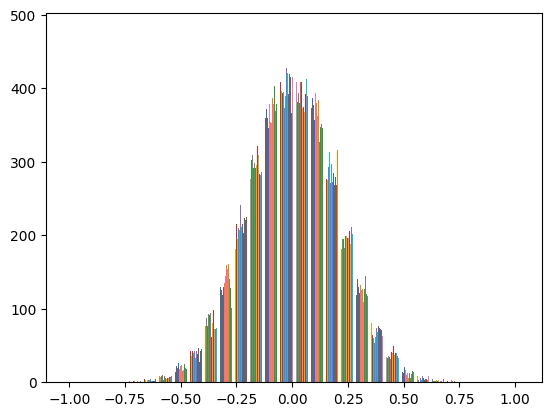

In [21]:
# Standard deviation of the random weight generation at the hidden layer
sigma = 0.2
# Number of inputs for the CIFAR10 dataset: 3073
# Take 2000 hidden neurons for the CIFAR10 dataset.
V  = sigma * np.random.randn(3073, 2000)
max_value = max([max(l) for l in V])
min_value = min([min(l) for l in V])
print('The larger weigth of the neural network hidden layer is:', max_value)
print('The smaller weigth of the neural network hidden layer is:', min_value)
plt.hist(V, bins = 30)
plt.show()

In [22]:
c_values = [pow(2,d) for d in range(-8, 21, 2)] # Range goes up to 21 to ensure search up to 2^20

hit_rates_training, Ws = get_rates_from_c_values(get_h(X_training_elm, V, relu), y_training, c_values)

0.00390625
0.015625
0.0625
0.25
1
4
16
64
256
1024
4096
16384
65536
262144
1048576


In [23]:
hit_rates_validation, _ = get_rates_from_c_values(get_h(X_validation_elm, V, relu), y_validation, c_values, Ws)

0.00390625
0.015625
0.0625
0.25
1
4
16
64
256
1024
4096
16384
65536
262144
1048576


Best c value: 4096 
Performance of this value: 0.46273333333333333


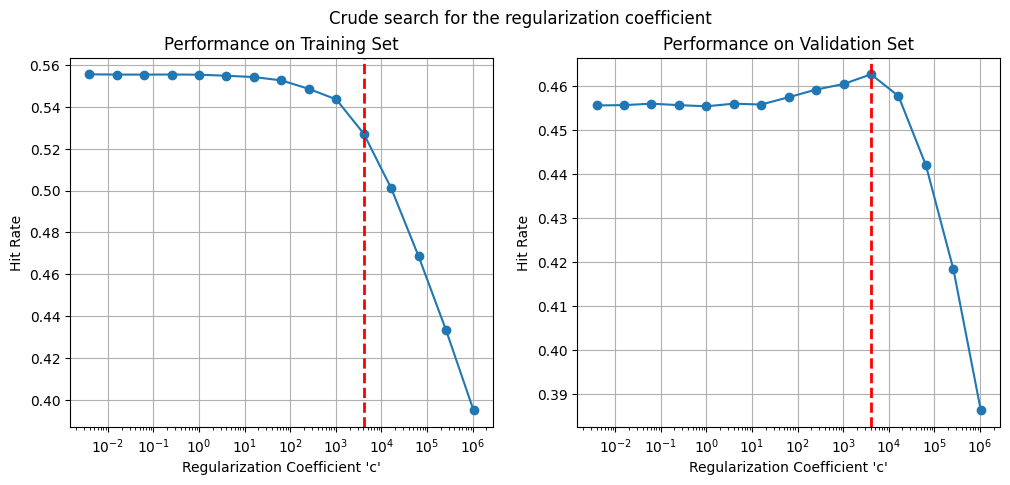

In [24]:
best_c_index = np.where(hit_rates_validation == np.amax(hit_rates_validation))[0][0]

best_c = c_values[best_c_index]

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.suptitle("Crude search for the regularization coefficient")
axs[0].semilogx(c_values, hit_rates_training, 'o-')
axs[0].set_title("Performance on Training Set")
axs[0].set_ylabel("Hit Rate")
axs[0].set_xlabel("Regularization Coefficient 'c'")
axs[0].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[0].grid()

axs[1].semilogx(c_values, hit_rates_validation, 'o-')
axs[1].set_title("Performance on Validation Set")
axs[1].set_ylabel("Hit Rate")
axs[1].set_xlabel("Regularization Coefficient 'c'")
axs[1].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[1].grid()

print("Best c value: {} \nPerformance of this value: {}".format(best_c, hit_rates_validation[best_c_index]))


**Nota**: Ao analisar o gráfico da direita acima, só corrija o intervalo de busca caso não haja uma queda de desempenho para valores elevados do coeficiente de regularização. Caso o melhor coeficiente de regularização seja o de menor valor, siga adiante, pois isso indica a ausência de necessidade de regularizar esta solução.

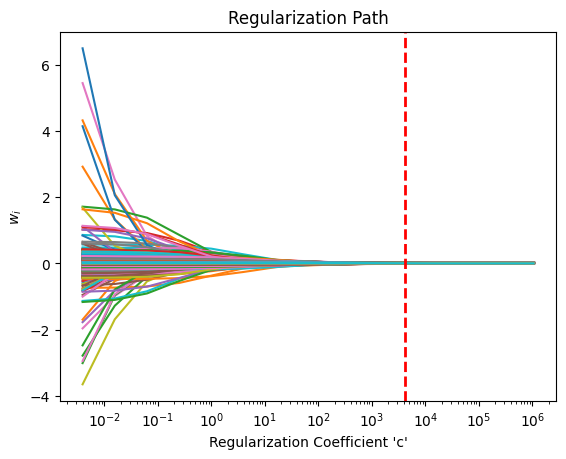

In [25]:
lambd_values = c_values
w_values = Ws

def plot_regularization_path(lambd_values, w_values):
    num_coeffs = len(w_values[0])
    for i in range(num_coeffs):
        plt.plot(lambd_values, [wi[i] for wi in w_values])
    plt.xlabel(r"Regularization Coefficient 'c'", fontsize=10)
    plt.ylabel(r"$w_i$", fontsize=10)
    plt.xscale("log")
    plt.title("Regularization Path")

plot_regularization_path(lambd_values, w_values)
plt.axvline(x=best_c, color='r', linestyle='--', linewidth=2)
plt.show()

In [26]:
step =  0.1 * (4 * best_c - best_c / 4);

fine_c_values = np.arange((best_c/4), (4*best_c) + step / 10, step)

hit_rates_training_fine, Ws_fine = get_rates_from_c_values(get_h(X_training_elm, V, relu), y_training, fine_c_values)

1024.0
2560.0
4096.0
5632.0
7168.0
8704.0
10240.0
11776.0
13312.0
14848.0
16384.0


In [ ]:
hit_rates_validation_fine, _ = get_rates_from_c_values(get_h(X_validation_elm, V, relu), y_validation, fine_c_values, Ws_fine)

Best c value: 4096.0 
Performance of this value: 0.9405555555555556


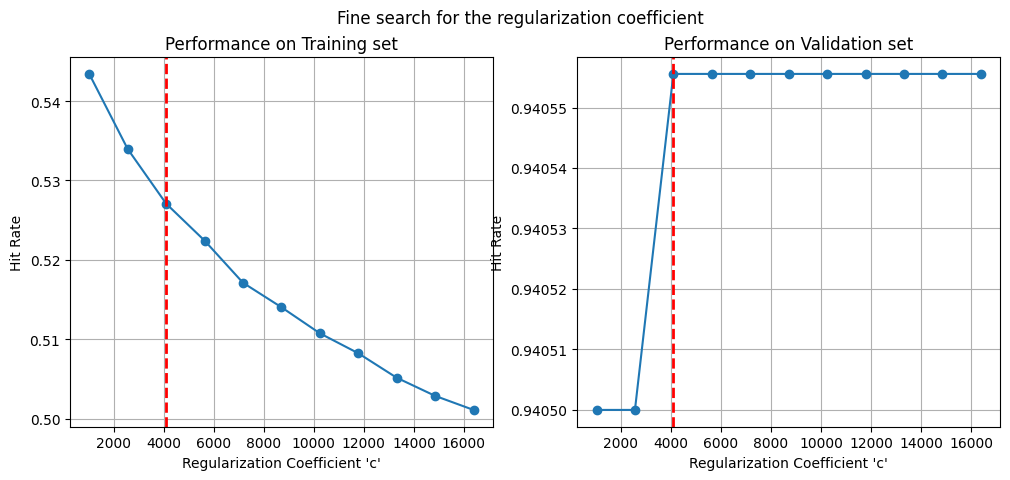

In [27]:
best_c_index = np.where(hit_rates_validation_fine == np.amax(hit_rates_validation_fine))[0][0]

best_c = fine_c_values[best_c_index]

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.suptitle("Fine search for the regularization coefficient")
axs[0].plot(fine_c_values, hit_rates_training_fine, 'o-')
axs[0].set_title("Performance on Training set")
axs[0].set_ylabel("Hit Rate")
axs[0].set_xlabel("Regularization Coefficient 'c'")
axs[0].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[0].grid()

axs[1].plot(fine_c_values, hit_rates_validation_fine, 'o-')
axs[1].set_title("Performance on Validation set")
axs[1].set_ylabel("Hit Rate")
axs[1].set_xlabel("Regularization Coefficient 'c'")
axs[1].axvline(x=best_c, color='r', linestyle='--', linewidth=2)
axs[1].grid()

print("Best c value: {} \nPerformance of this value: {}".format(best_c, hit_rates_validation_fine[best_c_index]))

(2000, 10)
The larger weigth of the neural network output layer is: 0.019398869214843604
The smaller weigth of the neural network output layer is: -0.012550822112478918


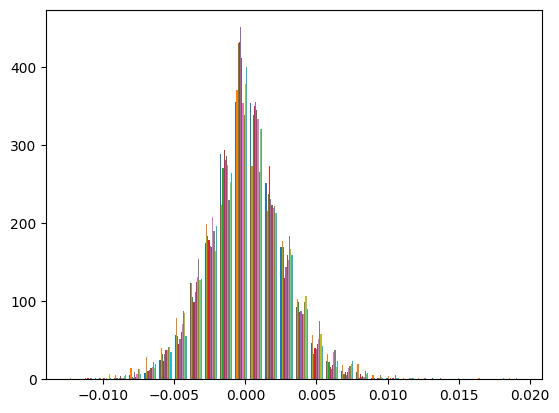

In [28]:
X_elm = np.concatenate((np.transpose(np.array([np.ones(X.shape[0])])), X), axis=1)
W_elm = get_w(get_h(X_elm, V, relu), yy, best_c)
print(W_elm.shape)
max_value = max([max(l) for l in W_elm])
min_value = min([min(l) for l in W_elm])
print('The larger weigth of the neural network output layer is:', max_value)
print('The smaller weigth of the neural network output layer is:', min_value)
plt.hist(W_elm, bins = 30)
plt.show()

In [29]:
Xt_elm = np.concatenate((np.transpose(np.array([np.ones(Xt.shape[0])])), Xt), axis=1)
yt_estimate = np.matmul(get_h(Xt_elm, V, relu),W_elm)
hits = 0
confusion_matrix = np.zeros([10, 10], dtype=int)
for index, estimate in enumerate(yt_estimate):
    max_index = np.where(estimate == np.amax(estimate))[0][0]
    estimated_class = max_index + 1
    if estimated_class == get_class_from_sample(yyt[index,:]):
        hits += 1
        confusion_matrix[estimated_class-1][estimated_class-1] += 1
    else:
        confusion_matrix[estimated_class-1][get_class_from_sample(yyt[index,:])-1] += 1

print("Performance on test set: {}".format(hits/yt_estimate.shape[0]))
confusion_matrix_df = pd.DataFrame(confusion_matrix)
confusion_matrix_df

Performance on test set: 0.4739


,0,1,2,3,4,5,6,7,8,9
0,529,38,113,49,69,30,16,44,90,44
1,50,572,38,62,25,40,31,45,81,184
2,47,8,315,69,135,81,65,59,11,8
3,16,26,65,252,40,151,51,48,19,24
4,23,8,108,53,398,61,97,58,12,12
5,13,14,71,182,48,356,51,58,21,15
6,28,34,137,151,134,96,587,32,15,39
7,47,40,79,75,95,101,43,541,24,52
8,188,79,47,38,33,50,26,33,658,91
9,59,181,27,69,23,34,33,82,69,531


<font color="green">
Atividade (c) <br>
Uma vez treinada uma ELM, que estratégia você adotaria para eliminar neurônios da camada intermediária, caso uma implementação prática indicasse uma limitação de memória? A sua resposta deve propor uma subrede ELM extraída da rede ELM completa já treinada, capaz de exibir máximo desempenho de generalização sem envolver etapas de retreinamento. Considere que o número de neurônios que precisam ser eliminados é uma porcentagem arbitrária do número total. Considere também que a sua estratégia não deve se basear na amplitude dos pesos individuais da camada de saída (essa seria uma estratégia possível, mas não deve ser adotada aqui). <br>
</font>

Resposta: Para reduzir a quantidade de neurônios da camada oculta sem olhar para os pesos de saída e sem precisar treinar a rede de novo, a melhor estratégia é focar nas respostas que a própria camada intermediária está entregando (ou seja, analisar a matriz de ativação $H$).

Como os pesos aleatórios já foram aplicados, nós podemos diminuir o tamanho da rede removendo neurônios com base em dois critérios principais:

1. Eliminar neurônios com baixa variância (menos ativos): A ideia aqui é calcular o quanto a resposta de cada neurônio (as colunas da matriz $H$) varia durante os dados de treino. Como a gente usa a ativação ReLU, é muito comum que alguns neurônios acabem "morrendo" (dando saída próxima de zero o tempo todo) ou tenham um comportamento praticamente constante. Como eles não ajudam a diferenciar as classes, podemos simplesmente ordenar os neurônios do que menos varia para o que mais varia, e então eliminar a porcentagem necessária partindo sempre dos de menor variância.

2. Eliminar neurônios redundantes (por correlação): Outra possibilidade é procurar por neurônios que estão fazendo exatamente o mesmo trabalho. Nós podemos calcular a correlação entre as saídas dos neurônios dessa camada. Se dois neurônios respondem de uma forma muito similar para as imagens (alta correlação), significa que eles estão passando informação "duplicada" para a camada da frente. Nesse caso, podemos identificar esses casos e manter apenas um representante, descartando o resto. Assim, conseguimos enxugar a porcentagem exigida da rede sem perder desempenho, já que só estamos jogando fora a redundância.